In [1]:
import os
import logging
import warnings
import numpy as np
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2025-12-26 20:00:13.169570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766779213.321480      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766779213.364813      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766779213.735741      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766779213.735782      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766779213.735785      55 computation_placer.cc:177] computation placer alr

# Setup

In [2]:
PATH = "cifar10"

EPOCHS       = 10
BATCH_SIZE   = 32
PATIENCE_ES  = 5
PATIENCE_REDUCELR_ON_PLATEAU = 3

MODEL_PATH   = "best_model.keras"
TFLITE_PATH  = "model_simple_int8.tflite"
MONITOR_MET  = "val_accuracy"
LR = 0.001

IMG_SIZE = (224, 224)
INPUT_SHAPE = (*IMG_SIZE, 3)

AUTOTUNE = tf.data.AUTOTUNE

# Dataset Load

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


val_size = len(x_test) // 2
x_val, y_val = x_test[:val_size], y_test[:val_size]
x_test, y_test = x_test[val_size:], y_test[val_size:]


y_train = tf.keras.utils.to_categorical(y_train, 10)
y_val = tf.keras.utils.to_categorical(y_val, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return preprocess_input(image), label

def prepare_dataset(x, y, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = prepare_dataset(x_train, y_train, is_training=True)
val_ds = prepare_dataset(x_val, y_val)
test_ds = prepare_dataset(x_test, y_test)


raw_train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE)
raw_train_ds.class_names = CLASS_NAMES

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


I0000 00:00:1766779235.772277      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


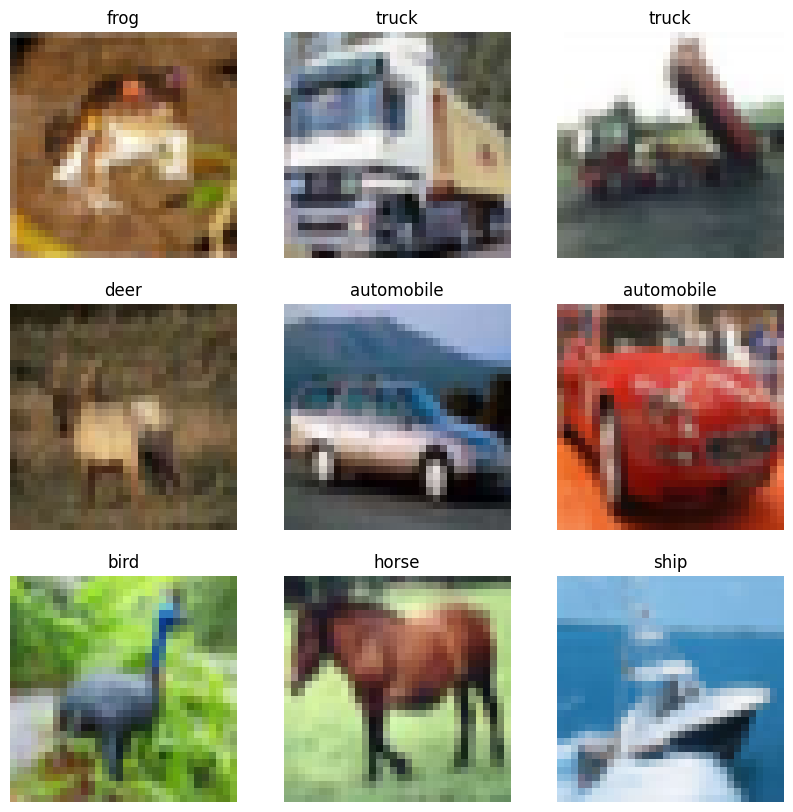

In [4]:
def plot_samples(dataset, num_samples=9):
    plt.figure(figsize=(10, 10))
    class_names = dataset.class_names

    for images, labels in dataset.take(1):
        for i in range(num_samples):
            ax = plt.subplot(3, 3, i + 1)
            img_array = images[i].numpy().astype("uint8")
            label_index = np.argmax(labels[i])

            plt.imshow(img_array)
            plt.title(class_names[label_index])
            plt.axis("off")
    plt.show()

plot_samples(raw_train_ds)

# Helpers

In [5]:
# -------------------------------------------------------------------
# 2) Helpers
# -------------------------------------------------------------------

def get_callbacks():
    return [
        EarlyStopping(monitor=MONITOR_MET, patience=PATIENCE_ES, verbose=0, restore_best_weights=True),
        ModelCheckpoint(MODEL_PATH,   monitor=MONITOR_MET, save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor=MONITOR_MET, factor=0.1, patience=PATIENCE_REDUCELR_ON_PLATEAU, min_lr=1e-6, verbose=1)
    ]

def plot_history(history):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

def evaluate_model(model, test_data, y_test=None):
    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"Acurácia final no test set: {acc:.4f}")
    return loss, acc

def predict_random_samples(model, dataset, class_names, num_samples=10):
    plt.figure(figsize=(15, 6))

    subset = dataset.unbatch().shuffle(buffer_size=1000, seed=None).take(num_samples)
    
    images = []
    true_labels = []

    for img, lbl in subset:
        images.append(img.numpy())
        true_labels.append(np.argmax(lbl.numpy()))

    images_arr = np.array(images)
    predictions = model.predict(images_arr, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)

    rows = int(np.ceil(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))
    
    if num_samples == 10:
        rows, cols = 2, 5

    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        img_display = (images_arr[i] * 255).astype("uint8")
        
        plt.imshow(img_display)
        
        is_correct = true_labels[i] == pred_labels[i]
        color = 'green' if is_correct else 'red'
        
        label_true = class_names[true_labels[i]]
        label_pred = class_names[pred_labels[i]]
        
        plt.title(f"T: {label_true}\nP: {label_pred}", color=color, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()



# Model

In [6]:
def create_balanced_model():
    inputs = tf.keras.Input(shape=INPUT_SHAPE)

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=INPUT_SHAPE
    )
    base_model.trainable = False

    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

In [7]:
print("Creating model...")
model = create_balanced_model()
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
     , jit_compile=False
)
model.summary()

Creating model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,914 (8.68 MB)

 Trainable params: 15,370 (60.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

# Train

In [8]:
print(f"\n Starting training - {EPOCHS} epochs (batch size={BATCH_SIZE})")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks(),
    verbose=1
)



 Starting training - 10 epochs (batch size=32)
Epoch 1/10


I0000 00:00:1766779247.074686     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 43ms/step - accuracy: 0.7349 - loss: 0.8150 - val_accuracy: 0.8410 - val_loss: 0.4868 - learning_rate: 0.0010
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.8261 - loss: 0.5197 - val_accuracy: 0.8406 - val_loss: 0.4758 - learning_rate: 0.0010
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.8323 - loss: 0.5008 - val_accuracy: 0.8444 - val_loss: 0.4710 - learning_rate: 0.0010
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.8375 - loss: 0.4851 - val_accuracy: 0.8506 - val_loss: 0.4609 - learning_rate: 0.0010
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.8359 - loss: 0.4829 - val_accuracy: 0.8502 - val_loss: 0.4606 - learning_rate: 0.0010
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.8412 - loss: 0.4703 - val_accuracy: 0.8480 - val_loss: 0.4618 - learning_rate: 0.0010
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8412 -

In [9]:
# Fine-tuning

print("\nStarting fine-tuning phase...")


base_model = model.layers[1]  
base_model.trainable = True


for layer in base_model.layers[:-30]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LR/10, weight_decay=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    jit_compile=False
)

print(f"Fine-tuning {sum([1 for layer in base_model.layers if layer.trainable])} layers")


history_ft = model.fit(
    train_ds,
    epochs=5,  
    validation_data=val_ds,
    callbacks=get_callbacks(),
    verbose=1
)

for key in history.history:
    history.history[key].extend(history_ft.history[key])


Starting fine-tuning phase...
Fine-tuning 30 layers
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 57ms/step - accuracy: 0.8312 - loss: 0.5241 - val_accuracy: 0.8702 - val_loss: 0.4782 - learning_rate: 1.0000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.9241 - loss: 0.2253 - val_accuracy: 0.8888 - val_loss: 0.4077 - learning_rate: 1.0000e-04
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 57ms/step - accuracy: 0.9507 - loss: 0.1393 - val_accuracy: 0.9002 - val_loss: 0.3737 - learning_rate: 1.0000e-04
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.9681 - loss: 0.0910 - val_accuracy: 0.8922 - val_loss: 0.4209 - learning_rate: 1.0000e-04
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.9784 - loss: 0.0614 - val_accuracy: 0.9086 - val_loss: 0.3877 - learning_rate: 1.0000e-04


In [10]:
print("\n Evaluating on test set")
evaluate_model(model, test_ds, None)
print(f"Number of classes {len(CLASS_NAMES)}"  )


 Evaluating on test set
Acurácia final no test set: 0.9142
Number of classes 10



 Plotting training curve


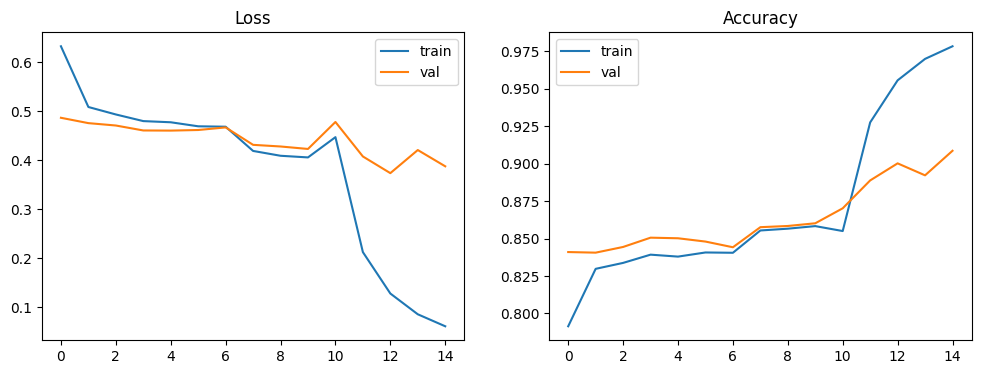

In [11]:
print("\n Plotting training curve")
plot_history(history)

# TFLite Export

In [ ]:
%%time

def create_representative_dataset_generator(dataset, num_samples=20):
    def representative_dataset():
        for images, _ in dataset.take(num_samples).unbatch().batch(1):
            yield [tf.cast(images, tf.float32)]
    return representative_dataset

def export_quantized_tflite(keras_model, representative_dataset_gen, tflite_path):
    print(f"\n Converting and quantizing to TFLite (INT8) at `{tflite_path}`...")
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.int8

    tflite_model_quant = converter.convert()

    with open(tflite_path, "wb") as f:
        f.write(tflite_model_quant)

    keras_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    tflite_size_kb = len(tflite_model_quant) / 1024
    print(f"✅ Export completed. Keras size: {keras_size_mb:.2f} MB | TFLite size: {tflite_size_kb:.1f} KB")


# Perform TFLite conversion and evaluation
representative_data_gen = create_representative_dataset_generator(train_ds)
export_quantized_tflite(model, representative_data_gen, TFLITE_PATH)

In [13]:
import numpy as np
import tensorflow as tf

def evaluate_tflite_universal(tflite_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero = input_details["quantization"]
    output_scale, output_zero = output_details["quantization"]

    correct = 0
    total = 0

    print(f"Avaliando TFLite Universal: {tflite_path}")

    for images, labels in dataset.unbatch().batch(1):
        img = images[0].numpy()
        lbl_raw = labels[0].numpy()

        if lbl_raw.size == 1:
            label = int(lbl_raw)
        else:
            label = np.argmax(lbl_raw)

        if input_details['dtype'] == np.uint8:
            img = img / input_scale + input_zero
            img = np.clip(img, 0, 255).astype(np.uint8)

        interpreter.set_tensor(input_details["index"], [img])
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]

        if output_details['dtype'] != np.float32:
             output = (output.astype(np.float32) - output_zero) * output_scale

        pred = np.argmax(output)

        if pred == label:
            correct += 1
        total += 1

    acc = correct / total if total > 0 else 0
    print(f"Accuracy TFLite: {acc:.4f}")
    return acc

In [14]:
evaluate_tflite_universal(TFLITE_PATH, test_ds)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Avaliando TFLite Universal: model_simple_int8.tflite
Accuracy TFLite: 0.8694


0.8694